# 01 — Exploratory Data Analysis

Understand the dataset structure, quality, and key patterns before modelling.

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')


## 1. Load Data

In [42]:
df = pd.read_csv('../data/churn.csv')

In [43]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Data Quality

Check shape, dtypes, missing values, and duplicates.

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [45]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

## 3. Target Distribution

The dataset is imbalanced (~80 % not churned, ~20 % churned).

In [47]:
df["churn"].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

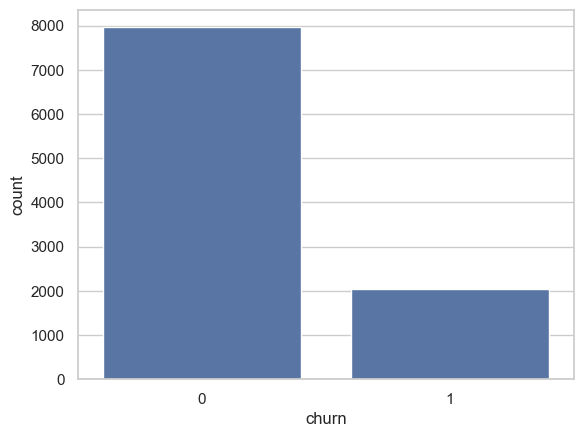

In [48]:
sns.countplot(x="churn", data=df)
plt.show()

## 4. Feature Exploration

Drop `customer_id` (not a feature) and explore key distributions.

In [49]:
df = df.drop("customer_id", axis=1)

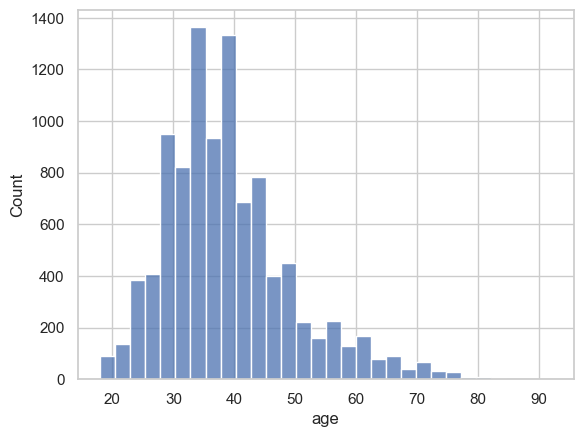

In [50]:
sns.histplot(df["age"], bins=30)
plt.show()

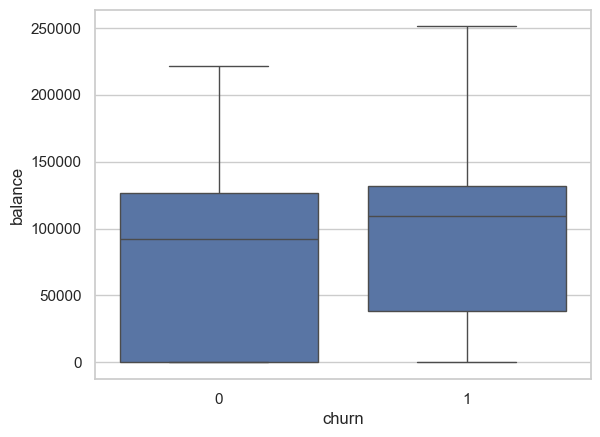

In [51]:
sns.boxplot(x="churn", y="balance", data=df)
plt.show()

## 5. Categorical Columns

In [52]:
df.select_dtypes(include="object").columns

C:\Users\Muhammad Awais\AppData\Local\Temp\ipykernel_13244\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['country', 'gender'], dtype='str')